# Guided Numeric Exploration — Critical Minerals & Rare Earths
_Mineral × country × year supply, concentration, export controls, and disruption risk (2015–2026)_

***

**Programming Language:** Python in the Jupyter Notebook Environment

**Dataset:** [sergionefedov/critical-minerals-and-rare-earths-20152026](https://www.kaggle.com/datasets/sergionefedov/critical-minerals-and-rare-earths-20152026)

**Style counterpart:** [Guided Numeric and Text Exploration — E-Commerce](https://www.kaggle.com/code/nicapotato/guided-numeric-and-text-exploration-e-commerce)

**Code Navigation:** <br>
In the code, text after hashtags (`#`) are supportive explanations, not executed as code.

***


# Tables of Content:

**1. [Introduction](#Introduction)** <br>
**2. [Setup and Data Peek](#Setup)** <br>
**3. [Univariate Supply & Risk](#Univariate)** <br>
**4. [Concentration and Export Controls](#Concentration)** <br>
**5. [Prices, End Uses, Disruptions](#Prices)** <br>
**6. [Forward Disruption Target](#Target)** <br>
**7. [What It Means — Working Synthesis](#Synthesis)** <br>

# **1. Introduction:** <a id="Introduction"></a> <br>
A **mineral × country × year** panel (1,548 rows; 24 minerals; 35 countries; 2015–2026) of simulated production, reserves, refining shares, prices, export controls, HHI concentration, and risk labels.

**Label caveats:** `supply_risk_score` is a computed index; `high_supply_risk` is the top 30% of that score (do not predict one from the other). `disruption_next_year` is the forward ML target and is **NaN for 2026**.


# **2. Setup and Data Peek:** <a id="Setup"></a>


In [1]:
# General
import numpy as np
import pandas as pd
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Scientific / modeling helpers
from IPython.display import display
from scipy import stats
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

import kagglehub

# Set Plot Theme (same family as the e-commerce guided notebook)
sns.set_palette([
    "#30a2da",
    "#fc4f30",
    "#e5ae38",
    "#6d904f",
    "#8b8b8b",
])
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Wide table inspection in Jupyter cell outputs
pd.set_option("display.max_columns", 999)
pd.set_option("display.width", 220)


/Users/nicapotato/Documents/repo/project/KaggleNotebooks/eda/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Code Explanation and Reasoning:** <br>
These packages fall into three buckets: *General*, *Visualization*, and *Scientific / modeling helpers*.

`pandas` / `numpy` hold the table; `matplotlib` / `seaborn` do the graphics; `scipy` and `sklearn` support light associational checks (correlations, RandomForest importances), not a production model. `kagglehub` resolves files both on Kaggle (`/kaggle/input/...`) and locally.

The five-color palette matches the guided e-commerce notebook so sequential plots feel like one continuous exploration.


In [2]:
# Read and Peak at Data
KAGGLE_SLUG = "sergionefedov/critical-minerals-and-rare-earths-20152026"
MASTER = "critical_minerals_supply_master.csv"
EXPECTED_COLS = [
    "year", "mineral", "country", "is_rare_earth", "end_use", "mine_production_tonnes",
    "production_share_pct", "reserves_tonnes", "years_of_reserves", "refined_share_pct",
    "price_usd_per_tonne", "demand_growth_pct", "export_control_active", "hhi",
    "top_country_share_pct", "supply_risk_score", "high_supply_risk", "disruption",
    "disruption_next_year",
]


def resolve_dataset_root() -> Path:
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        hits = list(kaggle_root.rglob(MASTER))
        assert hits, f"{MASTER} not under /kaggle/input"
        return hits[0].parent
    local_dir = Path("data") / "critical-minerals"
    if (local_dir / MASTER).exists():
        return local_dir
    root = Path(kagglehub.dataset_download(KAGGLE_SLUG))
    hits = list(root.rglob(MASTER))
    assert hits, f"expected {MASTER} under {root}"
    return hits[0].parent


root = resolve_dataset_root()
print("Dataset root:", root)
df = pd.read_csv(root / MASTER, low_memory=False)
missing = set(EXPECTED_COLS) - set(df.columns)
assert not missing, f"missing columns: {sorted(missing)}"
assert len(df) == 1548, len(df)
assert df["year"].min() == 2015 and df["year"].max() == 2026
assert df["mineral"].nunique() == 24
assert df.loc[df["year"] == 2026, "disruption_next_year"].isna().all()
assert df.loc[df["year"] < 2026, "disruption_next_year"].notna().all()

# Derived-label check: high_supply_risk is top ~30% of score
score_cut = df["supply_risk_score"].quantile(0.70)
print("Score p70:", round(score_cut, 2),
      "| high_risk rate:", round(df["high_supply_risk"].mean(), 3),
      "| score min among high_risk:", round(df.loc[df["high_supply_risk"] == 1, "supply_risk_score"].min(), 2))

dict_path = root / "data_dictionary.csv"
if dict_path.exists():
    display(pd.read_csv(dict_path).head(8))

unique_count = [[c, df[c].nunique(dropna=False), int(df[c].isnull().sum())] for c in df.columns]
print("Missing Values:", df.isnull().sum().sum())
print("REE share of rows: {:.1%}".format(df["is_rare_earth"].mean()))
print("Disruption rate:", round(df["disruption"].mean(), 3))


  0%|          | 0.00/45.6k [00:00<?, ?B/s]

100%|██████████| 45.6k/45.6k [00:00<00:00, 1.18MB/s]

Extracting files...


Dataset root: /Users/nicapotato/.cache/kagglehub/datasets/sergionefedov/critical-minerals-and-rare-earths-20152026/versions/1
Score p70: 48.29 | high_risk rate: 0.3 | score min among high_risk: 48.3


,column,type,description
0,year,int,Year (2015-2026)
1,mineral,string,Critical mineral / rare-earth element
2,country,string,Producing country
3,is_rare_earth,int,1 if a rare-earth element
4,end_use,string,"Primary end use (battery, magnet, semiconducto..."
5,mine_production_tonnes,float,Simulated mine production (metric tonnes)
6,production_share_pct,float,Country share of that mineral world production...
7,reserves_tonnes,float,Simulated reserves (metric tonnes)


Missing Values: 129
REE share of rows: 24.0%
Disruption rate: 0.046


**Code Explanation and Reasoning:** <br>
Master schema and year span are asserted. The 2026 nulls on `disruption_next_year` are required by the forward-target design. High-risk is treated as a derived threshold on `supply_risk_score`.


In [3]:
df.sample(5, random_state=7)


,year,mineral,country,is_rare_earth,end_use,mine_production_tonnes,production_share_pct,reserves_tonnes,years_of_reserves,refined_share_pct,price_usd_per_tonne,demand_growth_pct,export_control_active,hhi,top_country_share_pct,supply_risk_score,high_supply_risk,disruption,disruption_next_year
720,2015,Manganese,Australia,0,battery,2929343.2,15.85,92873930.0,31.7,12.68,1858.50,14.5,0,0.2060,35.55,11.5,0,0,0.0
1506,2021,Yttrium,Australia,1,phosphor,568.8,6.66,16167.0,28.4,5.33,66500.00,9.8,0,0.6135,74.99,53.8,1,1,0.0
713,2020,Lithium,Zimbabwe,0,battery,2766.7,4.23,33963.0,12.3,3.39,10800.00,21.1,0,0.2926,40.43,20.1,0,0,1.0
447,2018,Germanium,Russia,0,semiconductor,7.5,4.91,209.0,27.9,3.93,1424924.54,11.0,0,0.6437,77.43,61.4,1,0,0.0
684,2015,Lithium,Chile,0,battery,9671.5,28.38,475590.0,49.2,22.71,12000.00,14.5,0,0.2963,41.65,12.3,0,0,0.0


In [4]:
display(pd.DataFrame(unique_count, columns=["Column", "Unique", "Null"]).sort_values("Null", ascending=False))
df[["mine_production_tonnes", "hhi", "price_usd_per_tonne", "supply_risk_score"]].describe().T.round(2)


,Column,Unique,Null
18,disruption_next_year,3,129
10,price_usd_per_tonne,241,0
17,disruption,2,0
16,high_supply_risk,2,0
15,supply_risk_score,647,0
14,top_country_share_pct,280,0
13,hhi,277,0
12,export_control_active,2,0
11,demand_growth_pct,325,0
0,year,12,0


,count,mean,std,min,25%,50%,75%,max
mine_production_tonnes,1548.0,605215.16,1987323.07,4.60,413.25,7134.30,95263.35,24577711.60
hhi,1548.0,0.43,0.20,0.17,0.27,0.42,0.55,0.91
price_usd_per_tonne,1548.0,2668382.53,8744352.02,1100.00,10595.20,31528.98,229135.64,41604959.97
supply_risk_score,1548.0,37.67,19.20,0.00,21.30,36.60,51.50,100.00


**Interpretation** <br>
Each row is a producer country's contribution for a mineral-year, not a world aggregate. HHI and top-country share are mineral-year concentration fields duplicated across countries in that mineral-year.


# **3. Univariate Supply & Risk:** <a id="Univariate"></a>


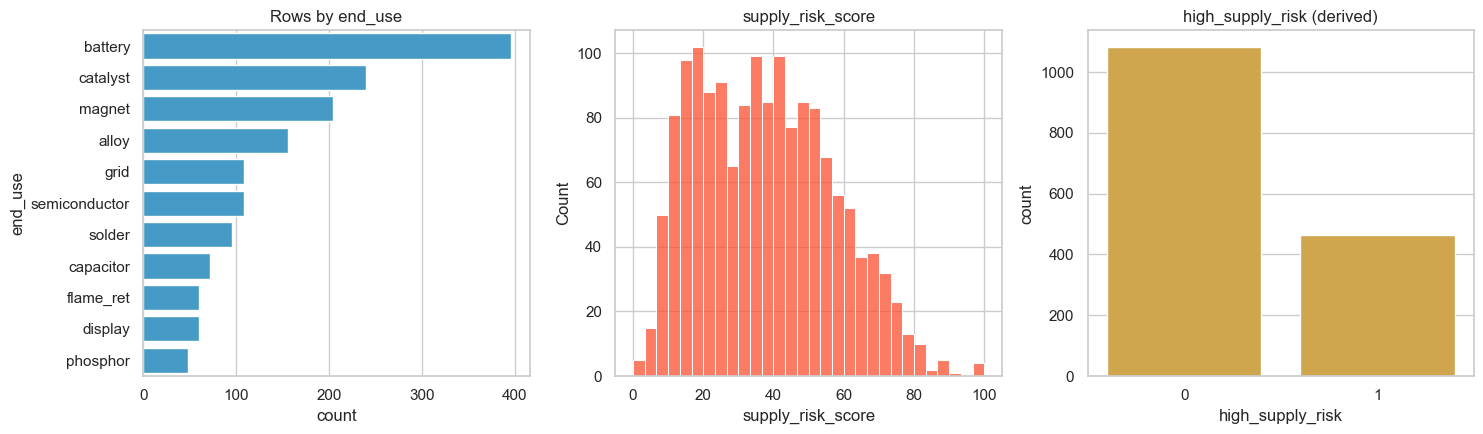

,hhi,top_country_share_pct,export_control_active,disruption
is_rare_earth,,,,
non-REE,0.390,53.695,0.016,0.031
REE,0.563,73.068,0.016,0.091


In [5]:
f, ax = plt.subplots(1, 3, figsize=(15, 4.5))
sns.countplot(data=df, y="end_use", order=df["end_use"].value_counts().index, ax=ax[0], color="#30a2da")
ax[0].set_title("Rows by end_use")
sns.histplot(df["supply_risk_score"], bins=30, ax=ax[1], color="#fc4f30")
ax[1].set_title("supply_risk_score")
sns.countplot(data=df, x="high_supply_risk", ax=ax[2], color="#e5ae38")
ax[2].set_title("high_supply_risk (derived)")
plt.tight_layout()
plt.show()

ree = df.groupby("is_rare_earth")[["hhi", "top_country_share_pct", "export_control_active", "disruption"]].mean()
display(ree.rename(index={0: "non-REE", 1: "REE"}).round(3))


**How to Interpret:** <br>
End-use mix shows which strategic segments the panel emphasizes (battery/magnet/…). REE vs non-REE means contrast concentration and control intensity.


# **4. Concentration and Export Controls:** <a id="Concentration"></a>


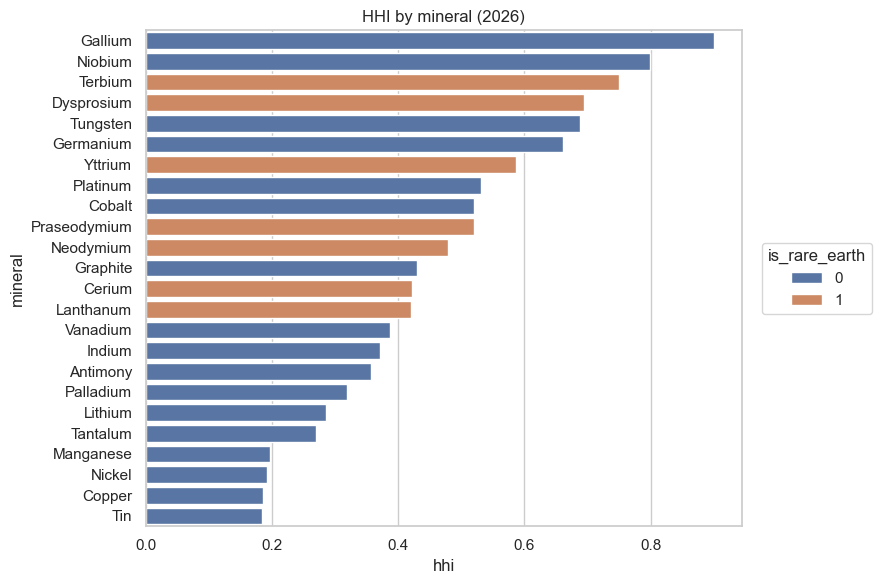

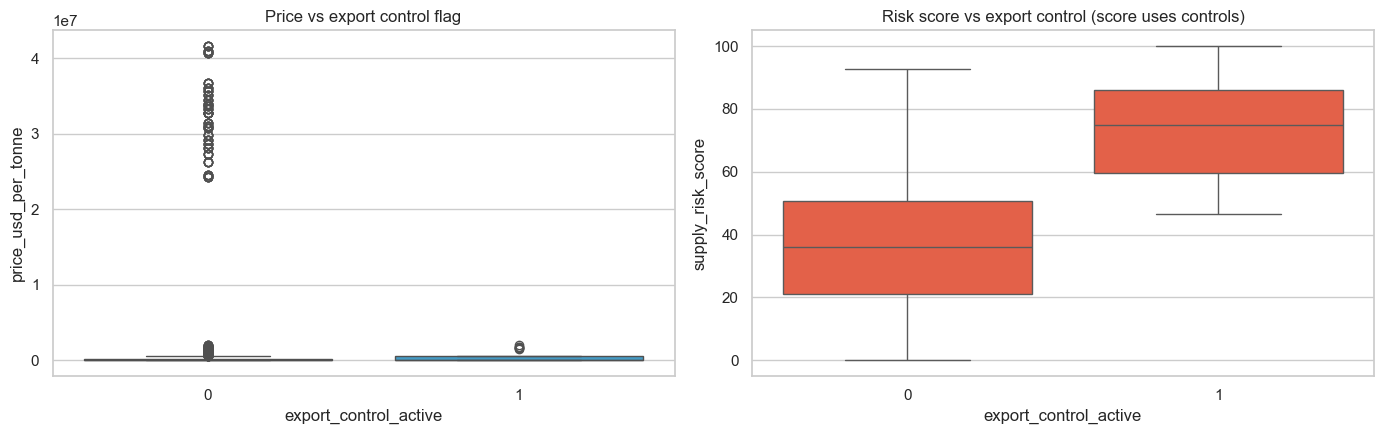

Note: supply_risk_score is computed partly from controls — right panel is partly by construction.


In [6]:
# Mineral-year concentration (dedupe country)
conc = df.drop_duplicates(["year", "mineral"])[["year", "mineral", "hhi", "top_country_share_pct", "is_rare_earth"]]
latest = conc[conc["year"] == conc["year"].max()].sort_values("hhi", ascending=False)
f, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=latest, y="mineral", x="hhi", hue="is_rare_earth", dodge=False, ax=ax)
ax.set_title(f"HHI by mineral ({int(conc['year'].max())})")
ax.legend(title="is_rare_earth", bbox_to_anchor=(1.02, 0.5), loc="center left")
plt.tight_layout()
plt.show()

f, ax = plt.subplots(1, 2, figsize=(14, 4.5))
sns.boxplot(data=df, x="export_control_active", y="price_usd_per_tonne", ax=ax[0], color="#30a2da")
ax[0].set_title("Price vs export control flag")
sns.boxplot(data=df, x="export_control_active", y="supply_risk_score", ax=ax[1], color="#fc4f30")
ax[1].set_title("Risk score vs export control (score uses controls)")
plt.tight_layout()
plt.show()
print("Note: supply_risk_score is computed partly from controls — right panel is partly by construction.")


**How to Interpret:** <br>
High HHI means concentrated mining. Export-control price boxes ask whether controlled mineral-country-years sit at different price levels. Risk-score vs controls is partly circular by design — do not overclaim causality.


# **5. Prices, End Uses, Disruptions:** <a id="Prices"></a>


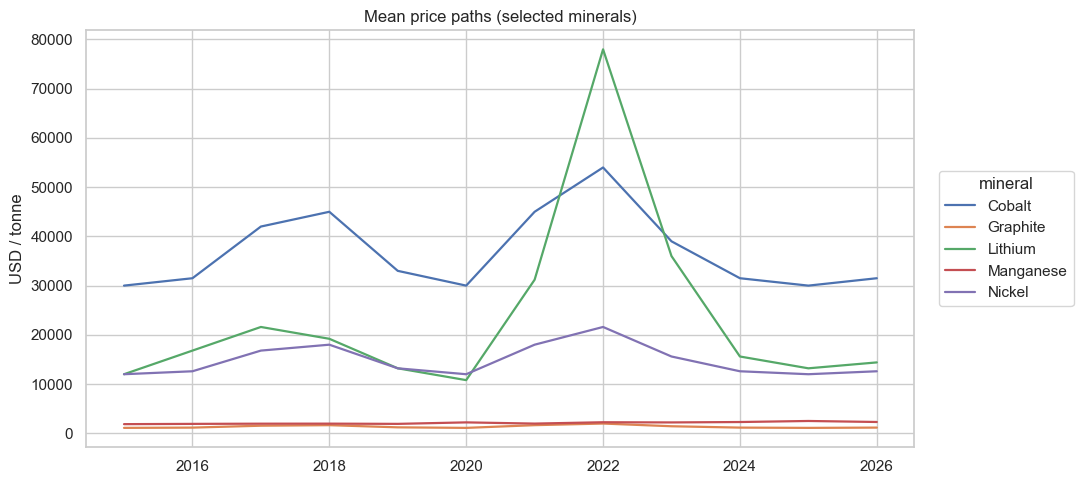

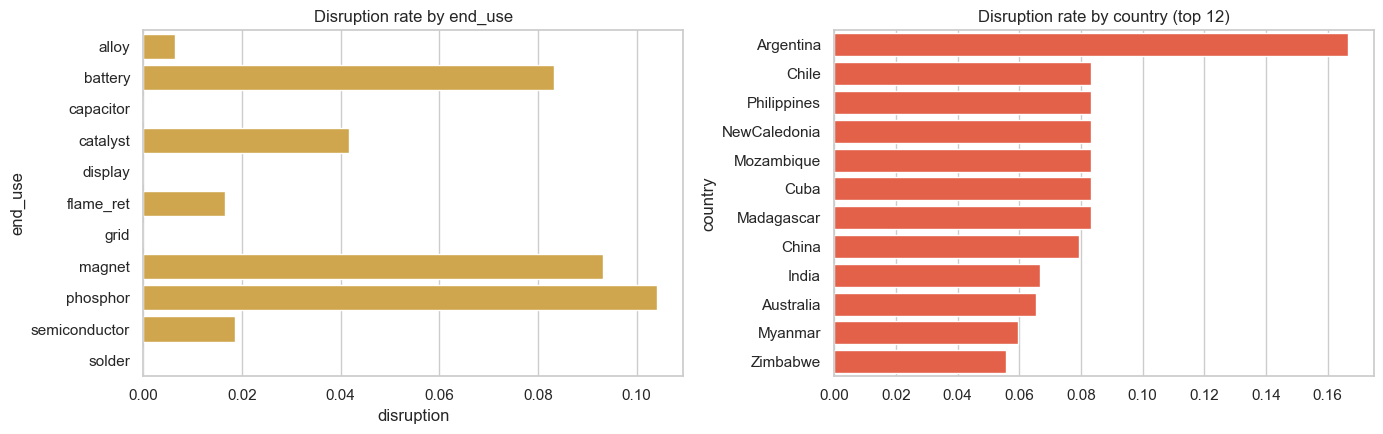

In [7]:
# World-ish price path: mean price across countries per mineral-year (prices often shared)
price = df.groupby(["year", "mineral", "end_use"], as_index=False)["price_usd_per_tonne"].mean()
# Focus battery minerals if present
battery_minerals = sorted(price.loc[price["end_use"] == "battery", "mineral"].unique())
plot_m = battery_minerals[:6] if battery_minerals else sorted(price["mineral"].unique())[:6]
f, ax = plt.subplots(figsize=(11, 5))
for m in plot_m:
    s = price[price["mineral"] == m]
    ax.plot(s["year"], s["price_usd_per_tonne"], label=m, lw=1.6)
ax.set_title("Mean price paths (selected minerals)")
ax.set_ylabel("USD / tonne")
ax.legend(title="mineral", bbox_to_anchor=(1.02, 0.5), loc="center left")
plt.tight_layout()
plt.show()

f, ax = plt.subplots(1, 2, figsize=(14, 4.5))
sns.barplot(
    data=df.groupby("end_use")["disruption"].mean().reset_index(),
    y="end_use", x="disruption", ax=ax[0], color="#e5ae38",
)
ax[0].set_title("Disruption rate by end_use")
top_c = df.groupby("country")["disruption"].mean().sort_values(ascending=False).head(12)
sns.barplot(x=top_c.values, y=top_c.index, ax=ax[1], color="#fc4f30")
ax[1].set_title("Disruption rate by country (top 12)")
plt.tight_layout()
plt.show()


**How to Interpret:** <br>
Price paths (e.g. lithium-like spikes) are the market narrative. Disruption rates by end-use/country show where the generator places shocks — still simulated geopolitics.


# **6. Forward Disruption Target:** <a id="Target"></a>


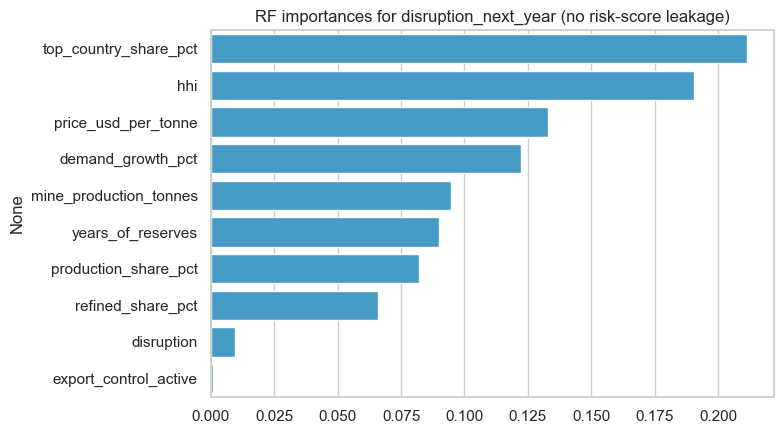

Base rate: 0.05 | in-sample accuracy: 0.98


In [8]:
# Pre-2026 only for next-year target
ml = df[df["year"] < 2026].copy()
assert ml["disruption_next_year"].notna().all()
ml["disruption_next_year"] = ml["disruption_next_year"].astype(int)

# Features that are NOT the derived high_risk/score tautology
feat_num = [
    "mine_production_tonnes", "production_share_pct", "refined_share_pct",
    "years_of_reserves", "price_usd_per_tonne", "demand_growth_pct",
    "export_control_active", "hhi", "top_country_share_pct", "disruption",
]
# Explicitly exclude supply_risk_score / high_supply_risk
X = ml[feat_num]
y = ml["disruption_next_year"]
rf = RandomForestClassifier(n_estimators=300, random_state=7, n_jobs=-1, max_depth=8)
rf.fit(X, y)
imp = pd.Series(rf.feature_importances_, index=feat_num).sort_values(ascending=False)
f, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(x=imp.values, y=imp.index, ax=ax, color="#30a2da")
ax.set_title("RF importances for disruption_next_year (no risk-score leakage)")
plt.tight_layout()
plt.show()
print("Base rate:", round(y.mean(), 3), "| in-sample accuracy:", round(rf.score(X, y), 3))


**How to Interpret:** <br>
This is an exploratory in-sample importance ranking on the forward target, excluding the computed risk score. Current-year `disruption` may still carry persistence — interpret carefully.


# **7. What It Means — Working Synthesis:** <a id="Synthesis"></a>

**What the table is:** <br>
A simulated critical-minerals geopolitics panel with computed risk labels and a forward disruption target.

**Working takeaways:** <br>
- Never train `high_supply_risk` from `supply_risk_score`.
- Drop 2026 when using `disruption_next_year`.
- Concentration, controls, and end-use prices are the story axes.

**Open follow-ups:** <br>
- Country share timelines for cobalt/nickel/REE.
- Walk-forward disruption models by year.
